# Test for code to transtion between lower tropospheric entrainment (dpmdz) and upper tropospheric entrainment (dmpdz_ut)
## This is controled by 2 pressure levels and dmpz transtions from dmpdz to dmpdz_ut between them.

In [36]:
import numpy as np
import matplotlib.pyplot as mp
import xarray as xr
import pandas as pd
import glob
import seaborn as sbn


print(xr.__version__)

2024.10.0


In [53]:
# PLOT LINES


dmpdz = -1e-3
dmpdz_ut = -1e-4

dmpdz_ltzlev = 1000.
dmpdz_utzlev = 5000.

ztop = 10000
zbot = 0
num_values = 100  # Number of values in the array

zht = np.linspace(zbot, ztop, num_values)

In [55]:
for iz,zz in enumerate(zht):


    zz_i = max(dmpdz_ltzlev,min(zz,dmpdz_utzlev))
    z_transition = (dmpdz_ltzlev-zz_i)/(dmpdz_ltzlev-dmpdz_utzlev)
    dmpdz_p =  dmpdz_ut*z_transition + dmpdz*(1-z_transition)
    print (iz, zz, zz_i,dmpdz_p,z_transition)

0 0.0 1000.0 -0.0001 -0.0
1 101.01010101010101 1000.0 -0.0001 -0.0
2 202.02020202020202 1000.0 -0.0001 -0.0
3 303.030303030303 1000.0 -0.0001 -0.0
4 404.04040404040404 1000.0 -0.0001 -0.0
5 505.0505050505051 1000.0 -0.0001 -0.0
6 606.060606060606 1000.0 -0.0001 -0.0
7 707.070707070707 1000.0 -0.0001 -0.0
8 808.0808080808081 1000.0 -0.0001 -0.0
9 909.0909090909091 1000.0 -0.0001 -0.0
10 1010.1010101010102 1010.1010101010102 -0.0001022727272727273 0.00252525252525254
11 1111.111111111111 1111.111111111111 -0.000125 0.027777777777777773
12 1212.121212121212 1212.121212121212 -0.0001477272727272727 0.053030303030303004
13 1313.1313131313132 1313.1313131313132 -0.00017045454545454547 0.07828282828282829
14 1414.141414141414 1414.141414141414 -0.0001931818181818182 0.10353535353535352
15 1515.1515151515152 1515.1515151515152 -0.00021590909090909093 0.1287878787878788
16 1616.1616161616162 1616.1616161616162 -0.00023863636363636364 0.15404040404040403
17 1717.171717171717 1717.171717171717 -0

In [ ]:
plt1, ax1 = mp.subplots(1,1,figsize=(16, 12)) # Ave plot of all cases
#sbn.color_palette("colorblind")
#colors = ['olive','coral','purple']
colors = ['blue','red','purple']

for ic,case in enumerate(cases):

    
    print()
    print('CASE = ',case)
    
    if ic > 1:
        ffile0 = fdir_s+case+'/run/'+case
    else:
        ffile0 = fdir_s+'archive/'+cases[ic]+'/atm/hist/'+case
    
    
    ffile = ffile0+'*h3i*2010*nc'
    print(ffile)
    flist  = sorted(glob.glob(ffile))
    fhist  =  xr.open_mfdataset(flist,parallel=True)  
    fhist  = fhist.sel(lat=lat_bounds, lon=lon_bounds, time=time_range)


    
    fvar = fhist[vname]
    vlong =  fvar.attrs['long_name']    
    fvar = vscale*fvar

    fprecc = fhist['PRECC']
    fprecc = vpscale*fprecc
    
    # Mask
    fvar = fvar.where(fprecc > 1.)
    
    # 1d-ize
    pvar_1d = fvar.values.ravel()
    print(pvar_1d[0:100])
        
    # PDF
    
    sbn.histplot(pvar_1d, binwidth=bwidth, binrange=(40, 1000),color=colors[ic],linewidth=1,multiple="layer",kde=True, fill=False,stat="probability", ) 

    del pvar_1d

leg = ax1.legend(cnames,loc='upper left',fontsize=29)

#ylims = [0.,5000]

ax1.set_xlim(xlims)
#ax1.set_ylim(ylims)
#plt1.gca().invert_yaxis()
ax1.set_title('3 hourly - '+vlong,fontsize=24)
ax1.set_ylabel('Relative frequency',fontsize=29) 
ax1.set_xlabel('Pressure (mb)',fontsize=29)
ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)
#ax1.vlines(0.,ylims[0] ,ylims[1], color='black',linestyle="dashed",lw=1)

for line in leg.get_lines():
    line.set_linewidth(4.0)

plt1.savefig('pdf_vres_'+vname+'_Jul.png', dpi=100, bbox_inches='tight') 

NameError: name 'pdf_data_proc' is not defined

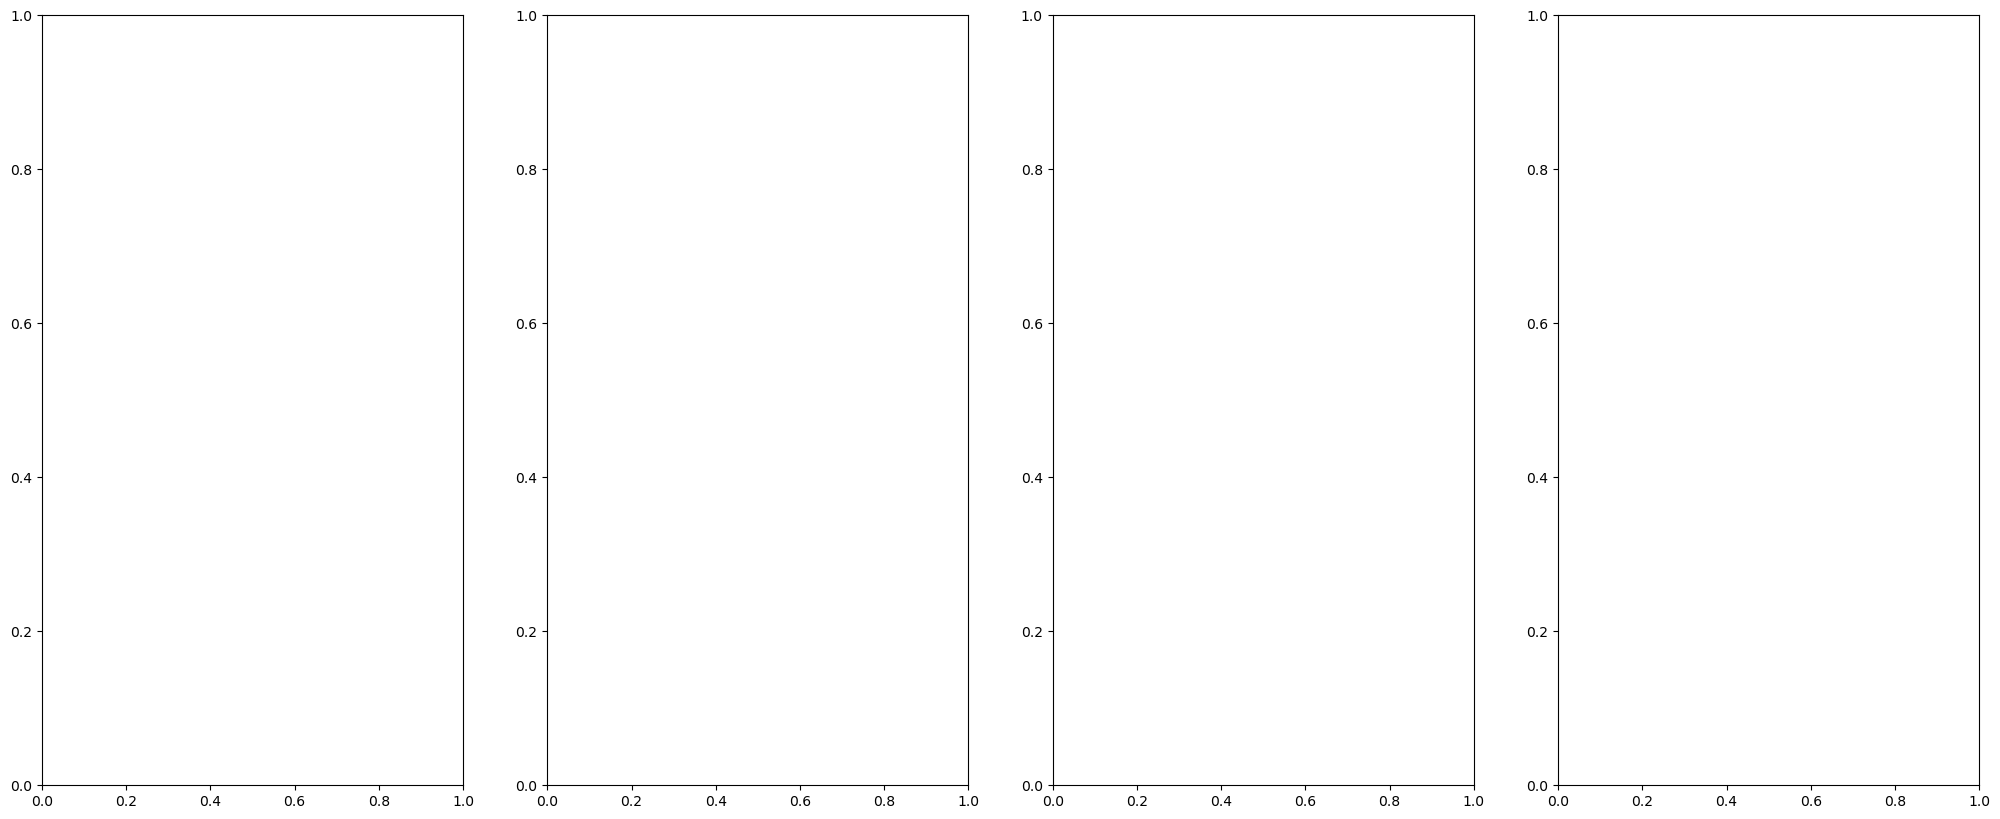

In [41]:
### 2D histogram ###

plt2, ax2 = mp.subplots(1,4,figsize=(25, 10)) # Ave plot of all cases

colors = ['black','skyblue','olive','coral']

for ic,case in enumerate(cases):

    fplot,vlong = pdf_data_proc(case,fdir0,vname,vscale) # Main variable
    fplotc,vlongc = pdf_data_proc(case,fdir0,vnamec,vscalec) # Always grab CONVECTIVE VARIABLE.
   
    

    ax2[ic].scatter(fplotc, fplot,color=colors[ic],alpha=0.1,marker='.',s=1)
    
#    ax2[ic].hist2d(fplotc, fplot, bins=(50, 50),range=([-50,10],[-20,50]))
    
    ax2[ic].vlines(0.,-60, 80, color='black',linestyle="dashed",lw=1)
    ax2[ic].hlines(0.,-60, 10, color='black',linestyle="dashed",lw=1)
    
    ax2[ic].set_title(cnames[ic],fontsize=24)
    ax2[ic].set_ylabel(vlong,fontsize=20) 
    ax2[ic].set_xlabel(vlongc,fontsize=15)
    ax2[ic].tick_params(axis='x', labelsize=16)
    ax2[ic].tick_params(axis='y', labelsize=16)
    
plt2.savefig('pdf_vres_scatter.png', dpi=100, bbox_inches='tight') 